# Tomato Leaf Disease Classification using CNN

This notebook demonstrates a complete workflow for classifying tomato leaf diseases using a Convolutional Neural Network (CNN) built with TensorFlow/Keras.

### Project Overview
- **Dataset**: [Tomato Dataset V2](https://www.kaggle.com/datasets/zunorain/tomato-dataset-v2) from Kaggle, containing ~30,000 images across 10 classes (9 diseases and 1 healthy).
- **Objective**: Develop a deep learning model to accurately identify tomato plant health issues from leaf images.

### Workflow Steps
1. **Data Acquisition**: Using `kagglehub` to download the dataset.
2. **Preprocessing**: Implementing `ImageDataGenerator` for data augmentation (rotation, zoom, flips) and normalization.
3. **Model Architecture**: A Sequential CNN with three convolutional layers, max-pooling, dropout for regularization, and a softmax output layer.
4. **Training**: Training the model for 10 epochs with the Adam optimizer.
5. **Evaluation**: Visualizing accuracy/loss trends and evaluating performance on a validation set.
6. **Export**: Saving the trained model as an `.h5` file for deployment.

### Requirements
- TensorFlow 2.x
- Kagglehub
- Matplotlib / Numpy

In [ ]:
import kagglehub

path = kagglehub.dataset_download("zunorain/tomato-dataset-v2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomato-dataset-v2' dataset.
Path to dataset files: /kaggle/input/tomato-dataset-v2


## 1. Data Acquisition
We use the `kagglehub` library to programmatically download the dataset from Kaggle. This ensures the latest version is retrieved and stored in a consistent path.

In [ ]:
import os

print(os.listdir(path))

['augmented_dataset']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")
    if dirs:
        print("Folders:", dirs[:10])


/kaggle/input/tomato-dataset-v2 -> 0 files
Folders: ['augmented_dataset']
/kaggle/input/tomato-dataset-v2/augmented_dataset -> 0 files
Folders: ['Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Tomato_Late_blight', 'Tomato__Tomato_mosaic_virus']
/kaggle/input/tomato-dataset-v2/augmented_dataset/Tomato_Leaf_Mold -> 2975 files
/kaggle/input/tomato-dataset-v2/augmented_dataset/Tomato__Tomato_YellowLeaf__Curl_Virus -> 3209 files
/kaggle/input/tomato-dataset-v2/augmented_dataset/Tomato_Bacterial_spot -> 3164 files
/kaggle/input/tomato-dataset-v2/augmented_dataset/Tomato_Septoria_leaf_spot -> 3112 files
/kaggle/input/tomato-dataset-v2/augmented_dataset/Tomato_healthy -> 3072 files
/kaggle/input/tomato-dataset-v2/augmented_dataset/Tomato_Spider_mites_Two_spotted_spider_mite -> 3104 files
/kaggle/input/tomato-dataset-v

In [ ]:
dataset_path = path + "/augmented_dataset"

print(dataset_path)
print(os.listdir(dataset_path))

/kaggle/input/tomato-dataset-v2/augmented_dataset
['Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Tomato_Late_blight', 'Tomato__Tomato_mosaic_virus']


## 2. Data Preprocessing and Augmentation
To improve model generalization and prevent overfitting, we use `ImageDataGenerator`.
- **Rescaling**: Normalizes pixel values from [0, 255] to [0, 1].
- **Augmentation**: Applies random rotations, zooms, and horizontal flips to the training images.
- **Validation Split**: Reserves 20% of the data for model evaluation during training.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 24492 images belonging to 10 classes.


In [ ]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 6117 images belonging to 10 classes.


In [ ]:
print(train_data.class_indices)

{'Tomato_Bacterial_spot': 0, 'Tomato_Early_blight': 1, 'Tomato_Late_blight': 2, 'Tomato_Leaf_Mold': 3, 'Tomato_Septoria_leaf_spot': 4, 'Tomato_Spider_mites_Two_spotted_spider_mite': 5, 'Tomato__Target_Spot': 6, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 7, 'Tomato__Tomato_mosaic_virus': 8, 'Tomato_healthy': 9}


In [ ]:
num_classes = len(train_data.class_indices)

print("Number of classes:", num_classes)

Number of classes: 10


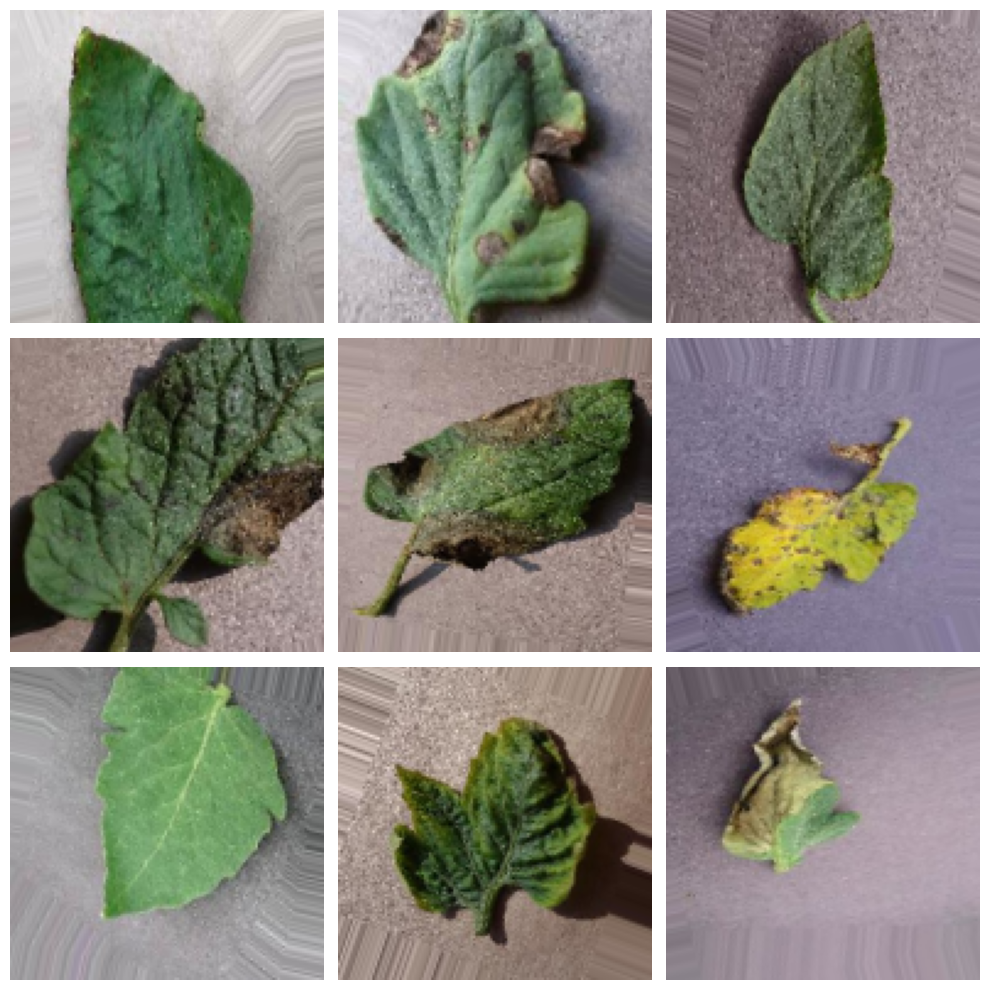

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Model Architecture
We define a Sequential CNN model. It consists of three convolutional blocks followed by max-pooling to extract spatial features. A dropout layer is included to reduce overfitting, and the final dense layer uses softmax activation for 10-class classification.

In [ ]:
model = Sequential([

    # Convolutional Layer 1
    Conv2D(32, (3, 3), activation='relu',
           input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Layer 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Layer 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout
    Dropout(0.5),

    # Output Layer - 10 classes
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training
The model is compiled using the Adam optimizer and categorical cross-entropy loss. We then train it for 10 epochs using our generated data streams.

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 276s 354ms/step - accuracy: 0.4820 - loss: 1.4407 - val_accuracy: 0.7232 - val_loss: 0.8046
Epoch 2/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 183s 239ms/step - accuracy: 0.6894 - loss: 0.8831 - val_accuracy: 0.7589 - val_loss: 0.7041
Epoch 3/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 182s 238ms/step - accuracy: 0.7661 - loss: 0.6821 - val_accuracy: 0.8473 - val_loss: 0.4494
Epoch 4/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 183s 239ms/step - accuracy: 0.7932 - loss: 0.6044 - val_accuracy: 0.8576 - val_loss: 0.4058
Epoch 5/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 199s 235ms/step - accuracy: 0.8201 - loss: 0.5253 - val_accuracy: 0.8496 - val_loss: 0.4361
Epoch 6/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 179s 233ms/step - accuracy: 0.8319 - loss: 0.4868 - val_accuracy: 0.8954 - val_loss: 0.3080
Epoch 7/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 180s 235ms/step - accuracy: 0.8531 - loss: 0.4291 - val_accuracy: 0.8789 - val_loss: 0.3592
Epoch 8/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 177s 231ms/step - accuracy: 0.8659 -

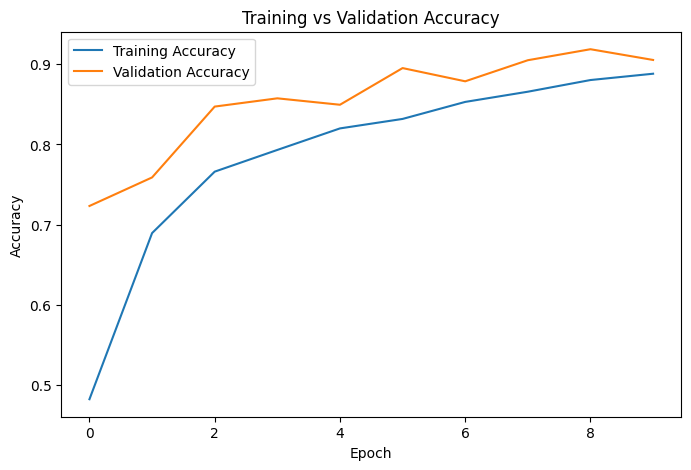

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

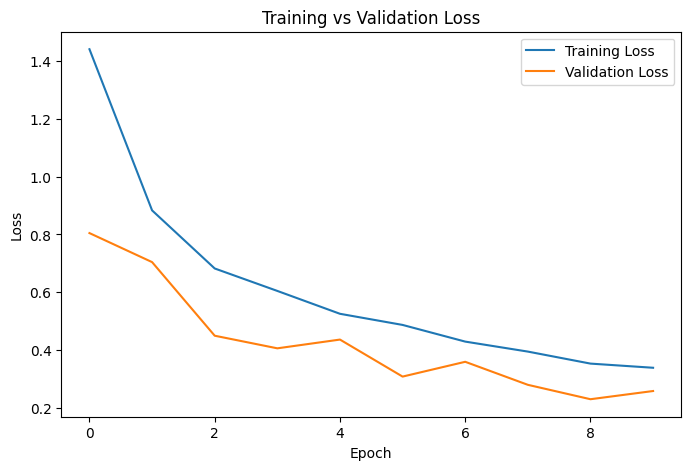

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 5. Evaluation and Export
Finally, we evaluate the model on the validation set to see its final performance metrics and export the weights to an `.h5` file for future use.

In [ ]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

192/192 ━━━━━━━━━━━━━━━━━━━━ 34s 178ms/step - accuracy: 0.9045 - loss: 0.2616
Validation Loss: 0.2615596354007721
Validation Accuracy: 0.9045283794403076


In [ ]:
model.save('/content/tomato_disease_cnn.h5')

In [ ]:
from google.colab import files

files.download('/content/tomato_disease_cnn.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>